In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

df = pd.read_csv('creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [2]:
cost_sensitive_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
cost_sensitive_model.fit(X_train_scaled, y_train)

y_proba_cs = cost_sensitive_model.predict_proba(X_test_scaled)[:, 1]
print("Model retrained, probabilities ready.")

Model retrained, probabilities ready.


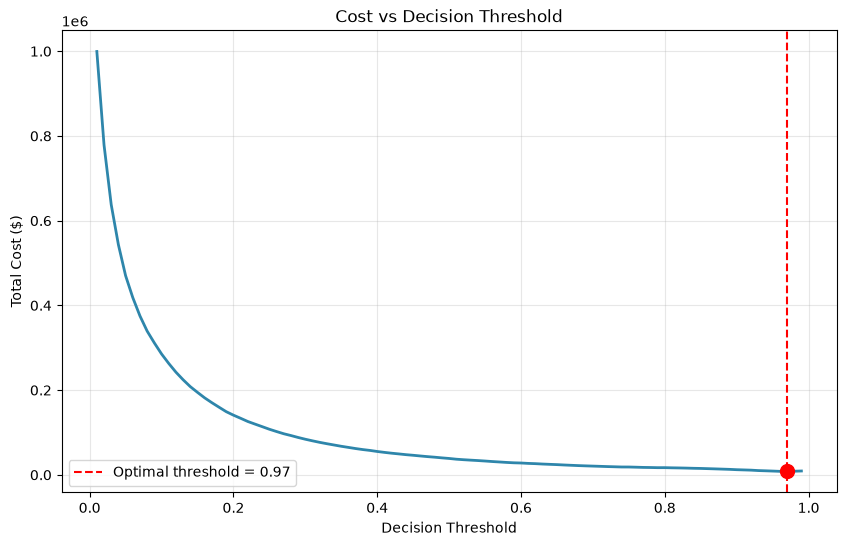

Optimal threshold: 0.97
Minimum cost: $7,875


In [4]:
import numpy as np
import matplotlib.pyplot as plt

FP_cost = 25
FN_cost = 500

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for threshold in thresholds:
    y_pred_t = (y_proba_cs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = fp * FP_cost + fn * FN_cost
    costs.append(total_cost)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, color='#2E86AB', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
plt.scatter([best_threshold], [best_cost], color='red', s=100, zorder=5)
plt.xlabel('Decision Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Cost vs Decision Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('cost_vs_threshold.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Minimum cost: ${best_cost:,}")

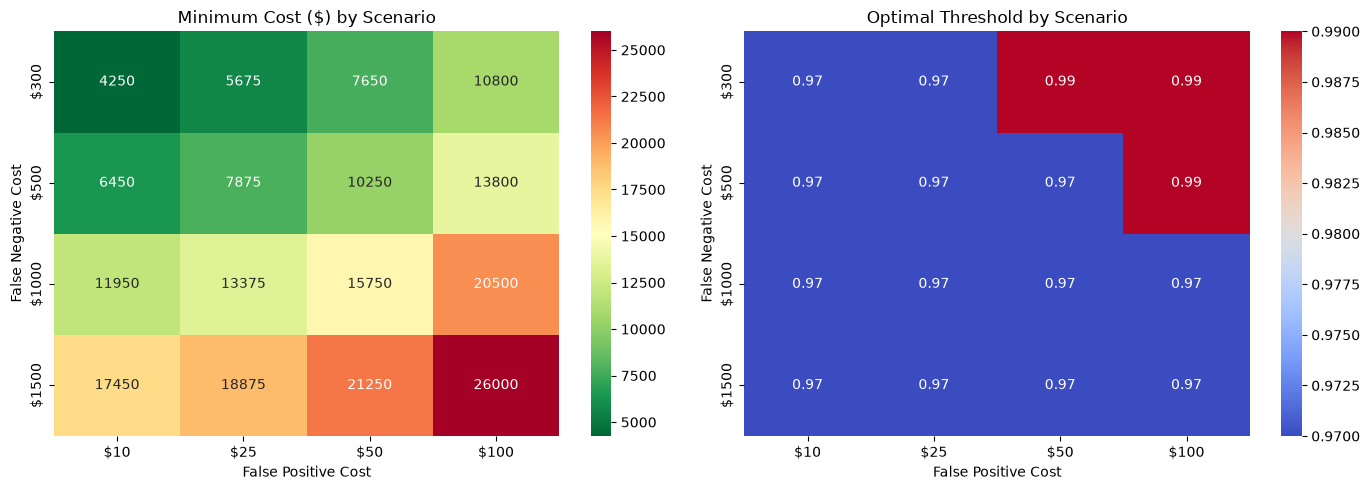

In [9]:
import seaborn as sns

fp_costs = [10, 25, 50, 100]
fn_costs = [300, 500, 1000, 1500]

sensitivity = np.zeros((len(fn_costs), len(fp_costs)))
best_thresh_matrix = np.zeros((len(fn_costs), len(fp_costs)))

for i, fn_c in enumerate(fn_costs):
    for j, fp_c in enumerate(fp_costs):
        best_cost = float('inf')
        best_t = 0.5
        for threshold in np.arange(0.01, 1.0, 0.02):
            y_pred_t = (y_proba_cs >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
            cost = fp * fp_c + fn * fn_c
            if cost < best_cost:
                best_cost = cost
                best_t = threshold
        sensitivity[i, j] = best_cost
        best_thresh_matrix[i, j] = best_t

fp_labels = [f'${c}' for c in fp_costs]
fn_labels = [f'${c}' for c in fn_costs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(sensitivity, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=axes[0], xticklabels=fp_labels, yticklabels=fn_labels)
axes[0].set_title('Minimum Cost ($) by Scenario')
axes[0].set_xlabel('False Positive Cost')
axes[0].set_ylabel('False Negative Cost')

sns.heatmap(best_thresh_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], xticklabels=fp_labels, yticklabels=fn_labels)
axes[1].set_title('Optimal Threshold by Scenario')
axes[1].set_xlabel('False Positive Cost')
axes[1].set_ylabel('False Negative Cost')

plt.tight_layout()
plt.savefig('sensitivity_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()